
# Diebold-Li Modelling applications of the Nelson-Siegel specification 

## Overview

We estimate a dynamic Diebold–Li (Nelson–Siegel) yield curve model in state-space form using Australian zero-coupon yield data. The data are taken from the Australian Office of Financial Management (AOFM) Data Hub: https://www.aofm.gov.au/data-hub. For each month, we observe a panel of zero yields across maturities and represent the entire curve using three latent factors: Level, Slope, and Curvature.

We avoid static PCA because it is a statistical atheoretical rotation, with factors orthogonal by construction and sample-dependent (sign/scale indeterminacy, loading drift). By contrast, a state-space Nelson–Siegel model delivers persistent, interpretable Level, Slope, Curvature factors with an explicit (e.g., AR(1)) transition equation, where a non-diagonal state-shock covariance (Q) permits contemporaneous co-movement among factor innovations, with Kalman filtering naturally handling measurement error (Durbin & Koopman, 2012).

In this implementation, we follow the Diebold–Li specification with a fixed decay parameter λ = 0.0609 calibrated for maturities measured in months. The observed 1–10 year maturities are therefore converted to 12–120 months when constructing the Nelson–Siegel factor loadings. For each month, we run a cross-sectional ordinary least squares regression of the zero-coupon yields on these loadings to obtain preliminary time series for the Level, Slope, and Curvature factors, and use the cross-sectional residuals to form a diagonal measurement-error covariance matrix H.

We then estimate a first-order vector autoregression for the three factors to obtain an intercept vector c, a 3×3 transition matrix A, a state innovation covariance matrix Q, and the implied unconditional mean μ. Combined with the Nelson–Siegel loading matrix Z(λ), this yields a linear Gaussian state-space system with measurement equation and transition equation.

Finally, we apply the Kalman filter to obtain filtered and smoothed estimates of the latent factors over time, and use the estimated transition dynamics to produce multi-step-ahead forecasts for both the factors and the yield curve at the observed maturities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

file_path = "AOFMYIELDSBIASC.xlsx"

df = pd.read_excel(file_path, sheet_name="zero yields")
df['Month'] = pd.to_datetime(df['Month'])

yields = df.loc[:, 'y(1)': 'y(10)'].to_numpy()
dates = df['Month'].to_numpy()
maturities_years = np.arange(1, 11, dtype=float)
maturities_months = maturities_years * 12.0

T, N = yields.shape
print("Data loaded. Shape (T x N_maturities):", yields.shape)
df.head()


Data loaded. Shape (T x N_maturities): (397, 10)


,Month,y(1),y(2),y(3),y(4),y(5),y(6),y(7),y(8),y(9),y(10)
0,1992-07-31,0.05161,0.05636,0.06212,0.06738,0.07189,0.07568,0.07886,0.08153,0.08378,0.08569
1,1992-08-31,0.06237,0.07297,0.07929,0.08267,0.08461,0.08597,0.08719,0.08841,0.08970,0.09104
2,1992-09-30,0.06213,0.07129,0.07737,0.08117,0.08367,0.08547,0.08692,0.08816,0.08930,0.09035
3,1992-10-31,0.06079,0.07115,0.07764,0.08119,0.08325,0.08469,0.08596,0.08722,0.08853,0.08988
4,1992-11-30,0.06218,0.07235,0.07908,0.08313,0.08569,0.08749,0.08893,0.09021,0.09139,0.09253


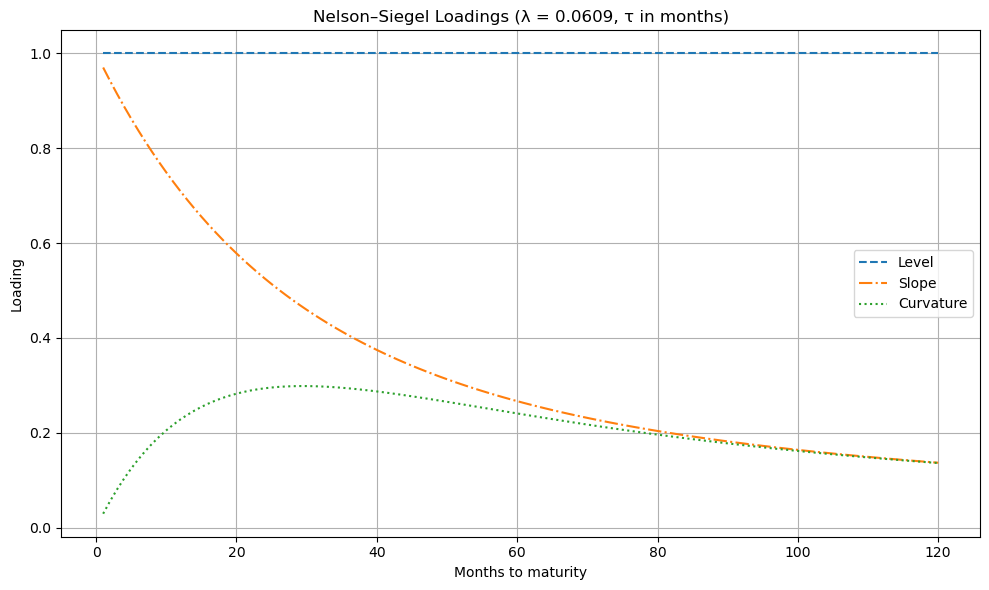

In [2]:
lambda_dl = 0.0609

def nelson_siegel_loadings(lam, tau):
    tau = np.asarray(tau, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        factor1 = np.ones_like(tau)
        factor2 = (1 - np.exp(-lam * tau)) / (lam * tau)
        factor3 = factor2 - np.exp(-lam * tau)
    return np.column_stack((factor1, factor2, factor3))

months = np.arange(1, 121)
Z_grid = nelson_siegel_loadings(lambda_dl, months)

plt.figure()
plt.plot(months, Z_grid[:,0], linestyle="--", label="Level")
plt.plot(months, Z_grid[:,1], linestyle="-.", label="Slope")
plt.plot(months, Z_grid[:,2], linestyle=":", label="Curvature")
plt.xlabel("Months to maturity")
plt.ylabel("Loading")
plt.title(f"Nelson–Siegel Loadings (λ = {lambda_dl:.4f}, τ in months)")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
X = nelson_siegel_loadings(lambda_dl, maturities_months)

betas_ols = np.zeros((T, 3))
residuals_cs = np.zeros_like(yields)

for t in range(T):
    y_t = yields[t,:]
    beta_hat, *_ = np.linalg.lstsq(X, y_t, rcond=None)
    betas_ols[t,:] = beta_hat
    residuals_cs[t,:] = y_t - X @ beta_hat

H_diag = residuals_cs.var(axis=0, ddof=1)
H = np.diag(H_diag)

print("First 5 OLS factor estimates (L, S, C):")
pd.DataFrame(betas_ols[:5,:], columns=["Level","Slope","Curvature"])


First 5 OLS factor estimates (L, S, C):


,Level,Slope,Curvature
0,0.101026,-0.047886,-0.067160
1,0.094987,-0.050086,0.013790
2,0.096334,-0.048693,0.001779
3,0.094303,-0.050633,0.011322
4,0.098394,-0.053025,0.006371


In [4]:
Y = betas_ols[1:,:]
X_var = betas_ols[:-1,:]
T_minus_1 = Y.shape[0]

X_design = np.column_stack([np.ones(T_minus_1), X_var])
B_hat, *_ = np.linalg.lstsq(X_design, Y, rcond=None)

c = B_hat[0,:]
A = B_hat[1:,:].T

Y_hat = X_design @ B_hat
eta = Y - Y_hat
Q = np.cov(eta.T, ddof=1)

I3 = np.eye(3)
mu = np.linalg.solve(I3 - A, c)

print("Intercept c:", c)
print("Transition matrix A:")
print(A)
print("\nUnconditional mean mu:", mu)
print("\nState covariance Q:")
print(Q)


Intercept c: [ 0.00159088  0.00045662 -0.00595659]
Transition matrix A:
[[ 9.78478556e-01  5.94650867e-03  2.84709673e-02]
 [ 3.08261879e-04  9.66601514e-01  4.15543392e-02]
 [ 3.05398292e-02 -9.22236415e-02  8.15412323e-01]]

Unconditional mean mu: [ 0.04507778 -0.01034937 -0.01964089]

State covariance Q:
[[ 8.43656932e-06 -7.30801429e-06 -2.52922018e-06]
 [-7.30801429e-06  1.47201246e-05 -4.34334946e-06]
 [-2.52922018e-06 -4.34334946e-06  7.51682661e-05]]


Kalman log-likelihood: 24291.727714272572


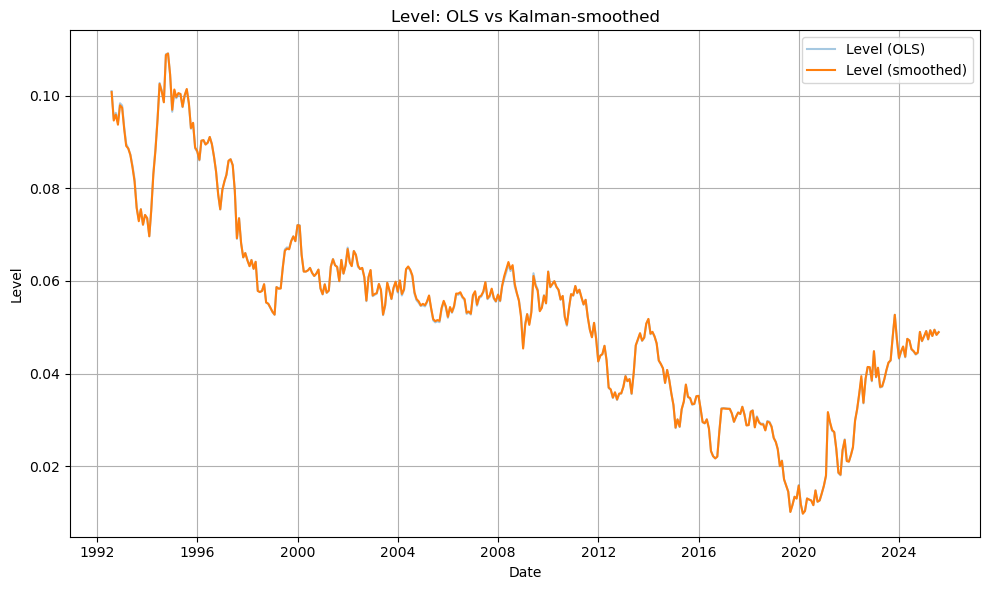

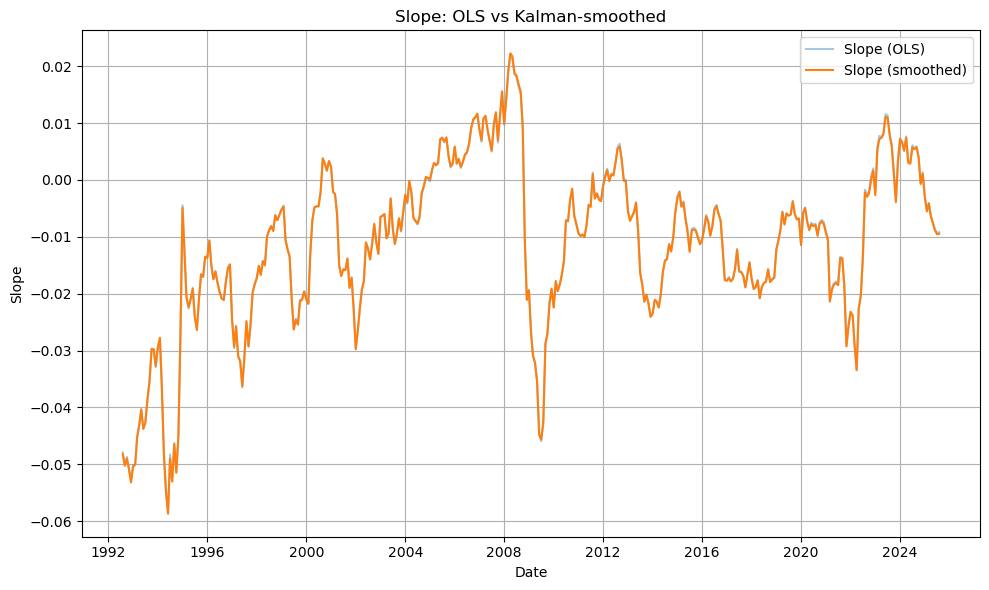

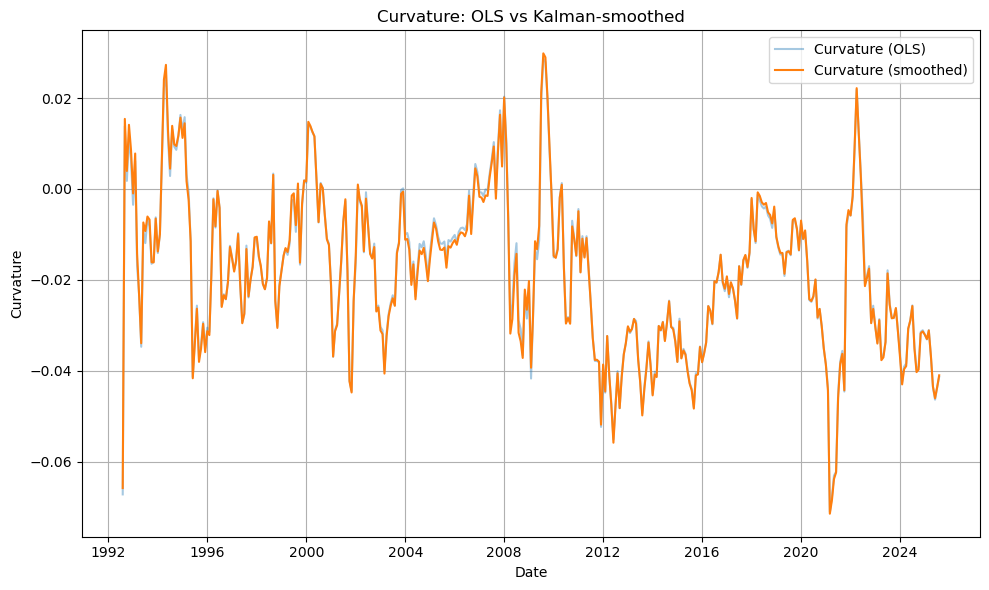

In [5]:
def kalman_filter(y, Z, c, A, Q, H, m0, P0):
    T_obs, N = y.shape
    m_tt = np.zeros((T_obs, 3))
    P_tt = np.zeros((T_obs, 3, 3))
    loglik = 0.0

    m_pred = m0.copy()
    P_pred = P0.copy()

    for t in range(T_obs):
        y_pred = Z @ m_pred
        S = Z @ P_pred @ Z.T + H
        v = y[t,:] - y_pred
        K = P_pred @ Z.T @ np.linalg.inv(S)
        m_upd = m_pred + K @ v
        P_upd = (np.eye(3) - K @ Z) @ P_pred

        m_tt[t,:] = m_upd
        P_tt[t,:,:] = P_upd

        sign, logdetS = np.linalg.slogdet(S)
        if sign <= 0:
            logdetS = np.log(np.abs(np.linalg.det(S)) + 1e-12)
        ll_t = -0.5 * (N*np.log(2*np.pi) + logdetS + v.T @ np.linalg.inv(S) @ v)
        loglik += ll_t

        m_pred = c + A @ m_upd
        P_pred = A @ P_upd @ A.T + Q

    return m_tt, P_tt, loglik

def kalman_smoother(m_tt, P_tt, c, A, Q):
    T_obs = m_tt.shape[0]
    m_tT = np.zeros_like(m_tt)
    P_tT = np.zeros_like(P_tt)

    m_tT[-1,:] = m_tt[-1,:]
    P_tT[-1,:,:] = P_tt[-1,:,:]

    for t in range(T_obs-2, -1, -1):
        P_pred = A @ P_tt[t,:,:] @ A.T + Q
        J = P_tt[t,:,:] @ A.T @ np.linalg.inv(P_pred)
        m_tT[t,:] = m_tt[t,:] + J @ (m_tT[t+1,:] - (c + A @ m_tt[t,:]))
        P_tT[t,:,:] = P_tt[t,:,:] + J @ (P_tT[t+1,:,:] - P_pred) @ J.T

    return m_tT, P_tT

Z = nelson_siegel_loadings(lambda_dl, maturities_months)
m0 = mu.copy()
P0 = np.eye(3)

m_filt, P_filt, loglik = kalman_filter(yields, Z, c, A, Q, H, m0, P0)
m_smooth, P_smooth = kalman_smoother(m_filt, P_filt, c, A, Q)

print("Kalman log-likelihood:", float(loglik))

plt.figure()
plt.plot(dates, betas_ols[:,0], label="Level (OLS)", alpha=0.4)
plt.plot(dates, m_smooth[:,0], label="Level (smoothed)")
plt.xlabel("Date"); plt.ylabel("Level"); plt.title("Level: OLS vs Kalman-smoothed")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(dates, betas_ols[:,1], label="Slope (OLS)", alpha=0.4)
plt.plot(dates, m_smooth[:,1], label="Slope (smoothed)")
plt.xlabel("Date"); plt.ylabel("Slope"); plt.title("Slope: OLS vs Kalman-smoothed")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(dates, betas_ols[:,2], label="Curvature (OLS)", alpha=0.4)
plt.plot(dates, m_smooth[:,2], label="Curvature (smoothed)")
plt.xlabel("Date"); plt.ylabel("Curvature"); plt.title("Curvature: OLS vs Kalman-smoothed")
plt.legend(); plt.tight_layout(); plt.show()


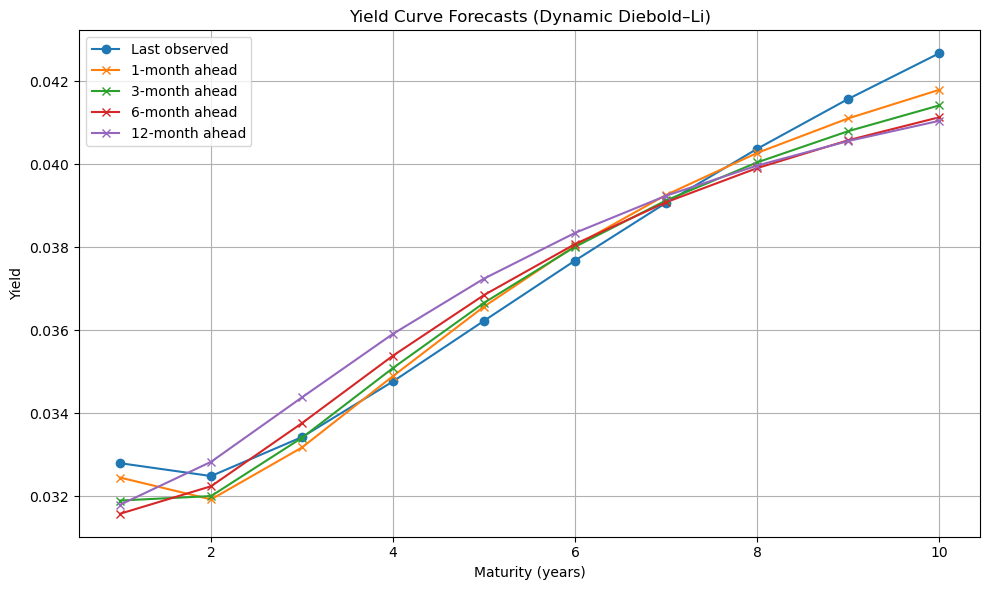

In [6]:
def forecast_factors(s_T, c, A, h):
    s = s_T.copy()
    out = []
    for _ in range(h):
        s = c + A @ s
        out.append(s.copy())
    return np.array(out)

h = 12
s_last = m_smooth[-1,:]
s_forecasts = forecast_factors(s_last, c, A, h)

y_forecasts = np.zeros((h, N))
for k in range(h):
    y_forecasts[k,:] = Z @ s_forecasts[k,:]

plt.figure()
plt.plot(maturities_years, yields[-1,:], marker="o", label="Last observed")
for k in [1,3,6,12]:
    if k <= h:
        plt.plot(maturities_years, y_forecasts[k-1,:], marker="x", label=f"{k}-month ahead")
plt.xlabel("Maturity (years)"); plt.ylabel("Yield")
plt.title("Yield Curve Forecasts (Dynamic Diebold–Li)")
plt.legend(); plt.tight_layout(); plt.show()
